# Deep Learning Models

PyTorch-based multi-layer perceptron (MLP) pipelines using cleaned feature matrix `../data/X_features.parquet` and grouped clinical outcomes from `../data/y_targets.parquet` (*any bleeding event*, *any ischemic event*, *any event at all*). This notebook trains a multi-output feed-forward neural network and reports cross-validated and held-out test performance, for comparison against the logistic regression, random forest and gradient boosting baselines.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

In [2]:
PROJECT_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
MODULE_DIR = os.path.join(PROJECT_DIR, 'simple_ml_models')
sys.path.append(MODULE_DIR)

from pipeline_utils import plot_confusion_matrices

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

## Load Dataset

Load the cleaned feature matrix `X` from `../data/X_features.parquet` and the 9 binary clinical outcome targets `y_df` from `../data/y_targets.parquet`, produced by the data cleaning pipeline.

In [3]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y_df = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

target_features = y_df

## Group Targets into Bleeding / Ischemic / Any-event Outcomes

As in `01_grouped_ML`, group the 9 individual endpoints into three broad binary outcomes: *any bleeding event* (the 5 BARC-based bleeding targets), *any ischemic event* (CV death, MI, stroke, revascularization), and *any event at all*. The MLP below is trained as a multi-output classifier on these 3 targets.

In [4]:
bleeding_targets = ['cec_barc3_335d', 'cec_barc35_335d', 'cec_barc2_335d', 'cec_barc235_335d', 'cec_bleed_335d']
ischemic_targets = [col for col in target_features.columns if col not in bleeding_targets]

y_bleeding = y_df[bleeding_targets].sum(axis=1).clip(0, 1)  # 1 if any bleeding endpoint occurred
y_ischemic = y_df[ischemic_targets].sum(axis=1).clip(0, 1)  # 1 if any ischemic endpoint occurred

y_generally = y_df.sum(axis=1).clip(0, 1)  # 1 if any endpoint occurred (bleeding or ischemic)

y_grouped = pd.concat([y_bleeding, y_ischemic, y_generally], keys=['bleeding', 'ischemic', 'generally'], axis=1)
y_grouped.value_counts()

bleeding  ischemic  generally
0         0         0            3840
1         0         1             432
0         1         1             233
1         1         1              74
Name: count, dtype: int64

## Train/Test Split

Split the data and keep numeric features only, as in `01_grouped_ML`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_grouped, test_size=0.2, random_state=RANDOM_STATE
)

X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

## MLP Model Definition

A small feed-forward network with two hidden layers and dropout. The output layer has 3 logits (one per target: bleeding, ischemic, generally) and is trained with `BCEWithLogitsLoss`, which applies an independent sigmoid to each output for multi-label classification. Batch normalization was tried but, combined with `pos_weight` below, made the network collapse to an (almost) constant ~0.5 output for every sample regardless of input, so it was left out.

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=(64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.BatchNorm1d(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

## Training & Evaluation Utilities

`train_model` runs a standard training loop (Adam optimizer + `BCEWithLogitsLoss`), optionally tracking validation loss. `pos_weight_from` computes a per-target loss weight from the class imbalance, the neural network analogue of `class_weight='balanced'` used for the sklearn models. `predict_proba` returns sigmoid probabilities for a fitted model, and `evaluate_mlp_cv` reports cross-validated F1 scores per target (refitting the scaler and the network on each fold), mirroring `evaluate_pipeline` from `01_grouped_ML`.

In [7]:
def make_loaders(X, y, batch_size=64, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(np.asarray(X, dtype=np.float32)),
        torch.tensor(np.asarray(y, dtype=np.float32)),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def pos_weight_from(y):
    y = np.asarray(y, dtype=np.float32)
    n_pos = y.sum(axis=0)
    n_neg = y.shape[0] - n_pos
    return torch.tensor(n_neg / np.clip(n_pos, 1, None), dtype=torch.float32)


def train_model(model, train_loader, val_loader=None, epochs=50, lr=1e-3, pos_weight=None, device=DEVICE):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device) if pos_weight is not None else None)
    
    
    from lion_pytorch import Lion

    optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)
    
    #optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        history['train_loss'].append(train_loss / len(train_loader.dataset))

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(model(xb), yb).item() * xb.size(0)
            history['val_loss'].append(val_loss / len(val_loader.dataset))

    return history


def predict_proba(model, X, device=DEVICE):
    model.eval()
    X_tensor = torch.tensor(np.asarray(X), dtype=torch.float32).to(device)
    with torch.no_grad():
        return torch.sigmoid(model(X_tensor)).cpu().numpy()


def evaluate_mlp_cv(X, y, cv=5, epochs=50, hidden_dims=(64, 32), dropout=0.3):
    cols = y.columns if hasattr(y, 'columns') else range(np.asarray(y).shape[1])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = np.zeros((cv, y.shape[1]))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        imputer = SimpleImputer(strategy='median')
        X_tr = imputer.fit_transform(X[train_idx])
        X_val = imputer.transform(X[val_idx])
        scaler = RobustScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
        y_tr, y_val = y[train_idx], y[val_idx]

        torch.manual_seed(RANDOM_STATE + fold)
        model = MLP(input_dim=X_tr.shape[1], output_dim=y.shape[1], hidden_dims=hidden_dims, dropout=dropout)
        train_model(model, make_loaders(X_tr, y_tr), epochs=epochs, pos_weight=pos_weight_from(y_tr))

        preds = (predict_proba(model, X_val) >= 0.5).astype(int)
        for i in range(y.shape[1]):
            scores[fold, i] = f1_score(y_val[:, i], preds[:, i], zero_division=0)

    for i, label in enumerate(cols):
        print(f'\n--- {label} ---')
        print(f'F1 scores: {scores[:, i]}')
        print(f'Mean F1:   {scores[:, i].mean():.4f} ± {scores[:, i].std():.4f}')

## Multi-output MLP Pipeline

Cross-validate the MLP on the training set (scaler and network are refit on each fold), then fit it on the full training set and report per-target classification metrics on the held-out test set.

In [8]:
print('Cross-validation on the training set')
evaluate_mlp_cv(X_train, y_train, cv=5, epochs=50)

Cross-validation on the training set



--- bleeding ---
F1 scores: [0.23561644 0.22727273 0.20465116 0.20366599 0.21777778]
Mean F1:   0.2178 ± 0.0125

--- ischemic ---
F1 scores: [0.15107914 0.18791946 0.14237288 0.16368286 0.16788321]
Mean F1:   0.1626 ± 0.0156

--- generally ---
F1 scores: [0.2459893  0.29288703 0.26872247 0.2862254  0.25695931]
Mean F1:   0.2702 ± 0.0175


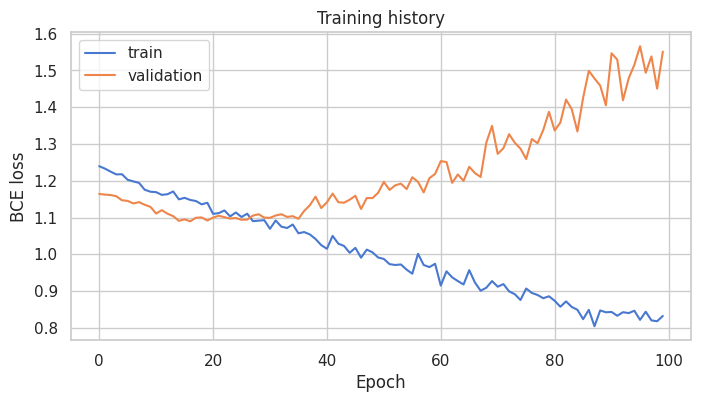

In [9]:
# Fit the scaler on the full training set, then hold out 10% of it to
# monitor validation loss while training the final model.
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.1, random_state=RANDOM_STATE
)

torch.manual_seed(RANDOM_STATE)
model = MLP(input_dim=X_train_scaled.shape[1], output_dim=y_train.shape[1])
history = train_model(
    model,
    make_loaders(X_fit, y_fit),
    val_loader=make_loaders(X_val, y_val, shuffle=False),
    epochs=100,
    pos_weight=pos_weight_from(y_fit),
)

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('BCE loss')
plt.title('Training history')
plt.legend()
plt.show()

Test set performance per target

--- bleeding ---
              precision    recall  f1-score   support

         0.0       0.90      0.61      0.73       807
         1.0       0.14      0.49      0.22       109

    accuracy                           0.60       916
   macro avg       0.52      0.55      0.47       916
weighted avg       0.81      0.60      0.67       916


--- ischemic ---
              precision    recall  f1-score   support

         0.0       0.94      0.78      0.85       857
         1.0       0.09      0.31      0.14        59

    accuracy                           0.75       916
   macro avg       0.52      0.54      0.50       916
weighted avg       0.89      0.75      0.81       916


--- generally ---
              precision    recall  f1-score   support

         0.0       0.85      0.66      0.74       763
         1.0       0.19      0.41      0.26       153

    accuracy                           0.61       916
   macro avg       0.52      0.53      0.

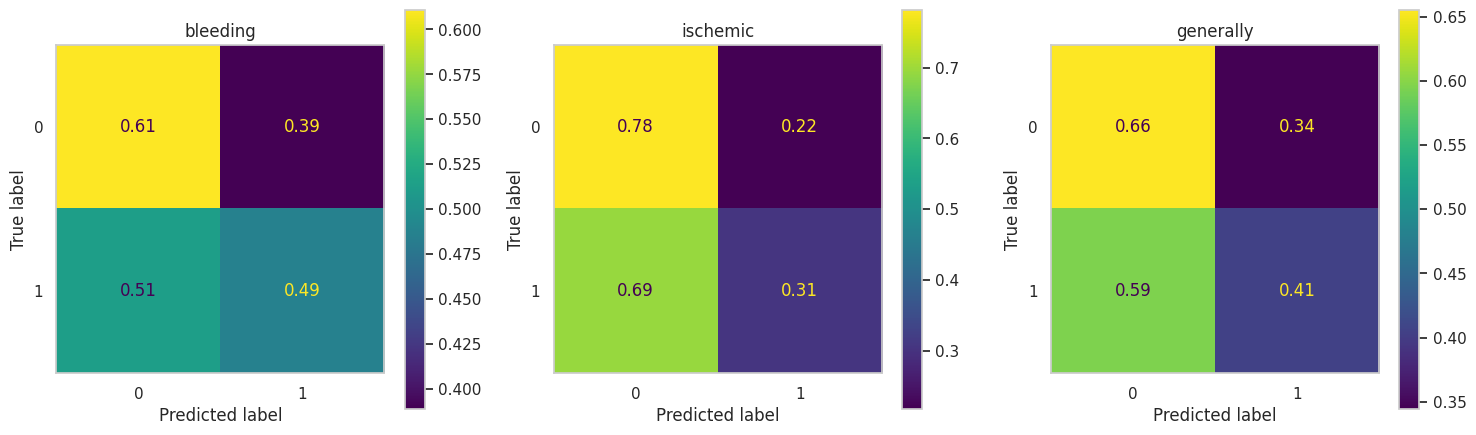

In [10]:
print('Test set performance per target')
# BCEWithLogitsLoss(pos_weight=...) reweights the loss during training so
# that, unlike the RandomForest/GradientBoosting baselines, the sigmoid
# output is centered close to 0.5 for these imbalanced targets, allowing the
# default 0.5 threshold to be used directly.
y_pred = (predict_proba(model, X_test_scaled) >= 0.5).astype(int)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, y_pred)